In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt #for plots
from sklearn.model_selection import train_test_split # for train test split
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [22]:
from pathlib import Path
folder_path = Path(r"/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000")

#print path


# List all files and directories
for file in folder_path.iterdir():
    print(file.name)  # prints just the name
    try:
        # Try to read as CSV
        df = pd.read_csv(file)   # file is already a full path
        print("shape:", df.shape)
        print(df.head())
    except Exception:
        if file.is_dir():
            # If it's a folder, count items inside
            num_items = len(list(file.iterdir()))
            print(f"Folder detected, contains {num_items} items")
        else:
            print("Not a CSV")


hmnist_8_8_RGB.csv
shape: (10015, 193)
   pixel0000  pixel0001  pixel0002  pixel0003  pixel0004  pixel0005  \
0        199        156        188        210        165        198   
1        115         87        115        180        133        158   
2        203        146        164        209        144        153   
3        135         96        110        198        141        156   
4        204        156        187        232        185        216   

   pixel0006  pixel0007  pixel0008  pixel0009  ...  pixel0183  pixel0184  \
0        216        176        203        215  ...        214        167   
1        200        153        187        215  ...        207        167   
2        217        160        181        215  ...        211        160   
3        208        148        158        210  ...        179        141   
4        236        196        220        217  ...        236        189   

   pixel0185  pixel0186  pixel0187  pixel0188  pixel0189  pixel0190  \
0     

important file is metadata, i still need to know what is the difference between the images folder. apparently they just split the images between both folder. one thing to do harmonize id with actual folders, maybe add as column

In [23]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [24]:
df.dx.value_counts() #  checking diagnosis value count 

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [26]:
df[df.age.isna()].dx.value_counts() # checking diagnosis value count where age is null

dx
nv     45
bkl    10
mel     2
Name: count, dtype: int64

Age was missing for 57 records (0.57% of the dataset). Because the missing values represented a very small fraction of the dataset and were not concentrated in the rarest diagnostic classes, records with missing age were removed before train/validation/test splitting.

In [33]:
image_dirs = [
    folder_path/"HAM10000_images_part_1",
    folder_path/"HAM10000_images_part_2"
]


image_path_map = {}

for image_dir in image_dirs:
    for image_path in image_dir.glob("*.jpg"):
        image_id = image_path.stem
        image_path_map[image_id] = str(image_path)

df["image_path"] = df["image_id"].map(image_path_map)

print("Images found in folders:", len(image_path_map))
print("Rows in metadata:", len(df))
print("Missing image paths:", df["image_path"].isna().sum())
print("Duplicate image IDs:", df["image_id"].duplicated().sum())

df[["image_id", "dx", "age", "sex", "localization", "image_path"]].head()

Images found in folders: 10015
Rows in metadata: 10015
Missing image paths: 0
Duplicate image IDs: 0


,image_id,dx,age,sex,localization,image_path
0,ISIC_0027419,bkl,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,ISIC_0025030,bkl,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,ISIC_0026769,bkl,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,ISIC_0025661,bkl,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,ISIC_0031633,bkl,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...


In [36]:
dropped_df= df[~df.age.isna()].copy()
dropped_df.shape

(9958, 8)

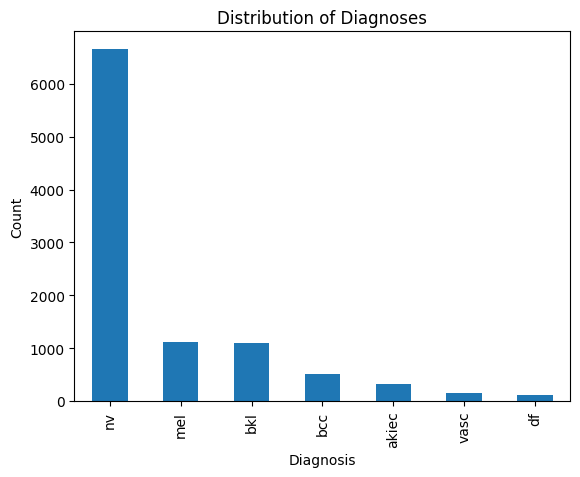

In [48]:
# Count each diagnosis and plot as bar chart
dropped_df["dx"].value_counts().plot(kind="bar")
plt.title("Distribution of Diagnoses")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.savefig("diagnosis_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
dropped_df["dx"].value_counts()

dx
nv       6660
mel      1111
bkl      1089
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [40]:
class_summary = (
    dropped_df["dx"]
    .value_counts()
    .rename_axis("dx")
    .reset_index(name="count")
)

class_summary["percent"] = (
    class_summary["count"] / class_summary["count"].sum() * 100
).round(2)

class_summary

,dx,count,percent
0,nv,6660,66.88
1,mel,1111,11.16
2,bkl,1089,10.94
3,bcc,514,5.16
4,akiec,327,3.28
5,vasc,142,1.43
6,df,115,1.15


The dataset is highly imbalanced after removing 57 records with missing age. The majority class, melanocytic nevi (`nv`), contains 6,660 samples, while the smallest class, dermatofibroma (`df`), contains only 115 samples. This creates an imbalance ratio of approximately 58:1. Therefore, model performance will be evaluated using macro-F1, balanced accuracy, per-class recall, and confusion matrices rather than accuracy alone.

In [44]:
class_names = sorted(dropped_df["dx"].unique())

class_to_idx = {
    class_name: idx for idx, class_name in enumerate(class_names)
}
class_to_idx

idx_to_class = {
    idx: class_name for class_name, idx in class_to_idx.items()
}

dropped_df["label"] = dropped_df["dx"].map(class_to_idx)

print(class_to_idx)
dropped_df[["image_id", "dx", "label"]].head()

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


,image_id,dx,label
0,ISIC_0027419,bkl,2
1,ISIC_0025030,bkl,2
2,ISIC_0026769,bkl,2
3,ISIC_0025661,bkl,2
4,ISIC_0031633,bkl,2


In [46]:
train_df, temp_df = train_test_split(
    dropped_df,
    test_size=0.20,
    stratify=dropped_df["dx"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dx"],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (7966, 9)
Validation: (996, 9)
Test: (996, 9)


In [47]:
def split_distribution(split_df, split_name):
    dist = (
        split_df["dx"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename(split_name)
    )
    return dist

split_summary = pd.concat(
    [
        split_distribution(train_df, "train_percent"),
        split_distribution(val_df, "val_percent"),
        split_distribution(test_df, "test_percent"),
    ],
    axis=1
)

split_summary

,train_percent,val_percent,test_percent
dx,,,
nv,66.88,66.87,66.87
mel,11.16,11.14,11.14
bkl,10.93,10.94,10.94
bcc,5.16,5.12,5.22
akiec,3.28,3.31,3.31
vasc,1.43,1.41,1.41
df,1.15,1.20,1.10


In [50]:
label_mapping = pd.DataFrame([
    {
        "dx": dx,
        "label": label
    }
    for dx, label in class_to_idx.items()
])

label_mapping

,dx,label
0,akiec,0
1,bcc,1
2,bkl,2
3,df,3
4,mel,4
5,nv,5
6,vasc,6


In [51]:
OUTPUT_DIR = Path("/kaggle/working/outputs")
FIGURE_DIR = Path("/kaggle/working/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

dropped_df.to_csv(OUTPUT_DIR / "metadata_clean.csv", index=False)
train_df.to_csv(OUTPUT_DIR / "train_split.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_split.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_split.csv", index=False)
label_mapping.to_csv(OUTPUT_DIR / "label_mapping.csv", index=False)